<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Comparing DBSCAN and HDBSCAN clustering 
Estimated time needed: **30** minutes
    

## Objectives


After completing this lab, you will be able to:

* Use scikit-learn to implement DBSCAN and HDBSCAN clustering models to real data
* Compare the performances of the two models 



## Introduction
In this lab, you'll create two clustering models using data curated by StatCan containing the names, types, and locations of
cultural and art facilities across Canada.
We'll focus on the museum locations provided across Canada.

#### Data source: The Open Database of Cultural and Art Facilities (ODCAF)

A collection of open data containing the names, types, and locations of cultural and art facilities across Canada. 
It is released under the Open Government License - Canada.
The different types of facilities are labeled under 'ODCAF_Facility_Type'.

#### Landing page:
https://www.statcan.gc.ca/en/lode/databases/odcaf

#### link to zip file:
https://www150.statcan.gc.ca/n1/en/pub/21-26-0001/2020001/ODCAF_V1.0.zip?st=brOCT3Ry


## Import the required libraries


In [16]:
# !pip install numpy==2.2.0
# !pip install pandas==2.2.3
# !pip install scikit-learn==1.6.0
# !pip install matplotlib==3.9.3
# !pip install hdbscan==0.8.40
# !pip install geopandas==1.0.1
# !pip install contextily==1.6.2
# !pip install shapely==2.0.6

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

# geographical tools
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

## Download the Canada map for reference

To get a proper context of the final output of this lab, you need a reference map of Canada. Execute the cell below to extract the same to this lab environment.


In [18]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


## Include a plotting function
The code for a helper function is provided to help you plot your results. Although you don't need to worry about the details, it's quite instructive as it uses a geopandas dataframe and a basemap to plot coloured cluster points on a map of Canada.


In [19]:
# Write a function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    
    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

## Explore the data and extract what you need from it


#### Start by loading the data set into a Pandas DataFrame and displaying the first few rows.


In [20]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")

In [21]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


### Exercise 1. Explore the table. What do missing values look like in this data set?


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  7972 non-null   int64 
 1   Facility_Name          7972 non-null   object
 2   Source_Facility_Type   7972 non-null   object
 3   ODCAF_Facility_Type    7972 non-null   object
 4   Provider               7972 non-null   object
 5   Unit                   7972 non-null   object
 6   Street_No              7972 non-null   object
 7   Street_Name            7972 non-null   object
 8   Postal_Code            7972 non-null   object
 9   City                   7972 non-null   object
 10  Prov_Terr              7972 non-null   object
 11  Source_Format_Address  7972 non-null   object
 12  CSD_Name               7972 non-null   object
 13  CSDUID                 7972 non-null   object
 14  PRUID                  7972 non-null   object
 15  Latitude             

In [23]:
df[df.isnull().any(axis=1)]

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude


In [24]:
df[df.isin(['..']).any(axis=1)]

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,9792,Zurich Libary,library,library or archives,huron county,..,10,goshen st n,N0M 2T0,huron county,on,"10 goshen st n, zurich, on n0m 2t0",Bluewater,3540010,35,43.4213556,-81.624695
7968,9797,Craigdarroch Castle,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.42241956,-123.3435527
7969,9798,..,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.4260053,-123.3691883
7970,9799,..,performance space - indoor venue,theatre/performance and concert hall,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.43154807,-123.3590685


In [25]:
df = df[~df.isin(['..']).any(axis=1)]

<details><summary>Click here for the solution</summary>
Strings consisting of two dots '..' indicate missing values. There miight still be empty fields, or NaNs.
</details>


### Exercise 2. Display the facility types and their counts.


In [26]:
# your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 52 to 7917
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  152 non-null    int64 
 1   Facility_Name          152 non-null    object
 2   Source_Facility_Type   152 non-null    object
 3   ODCAF_Facility_Type    152 non-null    object
 4   Provider               152 non-null    object
 5   Unit                   152 non-null    object
 6   Street_No              152 non-null    object
 7   Street_Name            152 non-null    object
 8   Postal_Code            152 non-null    object
 9   City                   152 non-null    object
 10  Prov_Terr              152 non-null    object
 11  Source_Format_Address  152 non-null    object
 12  CSD_Name               152 non-null    object
 13  CSDUID                 152 non-null    object
 14  PRUID                  152 non-null    object
 15  Latitude               152

<details><summary>Click here for the solution</summary>
    
```python
df.ODCAF_Facility_Type.value_counts()
```

</details>


### Exercise 3. Filter the data to only include museums.
Check your results. Did you get as many as you expected?


In [27]:
df

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
52,58,Écomusée De La Mi-Carême,museum / historic site,museum,province of québec,4,2,ch ernest,G4T 2W5,les-îles-de-la madeleine,qc,"04-2, ch. ernest",Les Îles-de-la-Madeleine,2401023,24,47.403476,-61.899131
131,154,Agora Des Arts,auditorium / theatre,theatre/performance and concert hall,province of québec,100,37,rue 7e,J9X 1Z6,rouyn-noranda,qc,"37, 7e rue bureau 100",Rouyn-Noranda,2486042,24,48.246317,-79.016785
229,276,Anahim Lake,cariboo regional district library system,library or archives,government of british columbia,1,2409,whispering hwy,V0L 1C0,castlegar,bc,"unit #1 - 2409 whispering pines trailer court,...",Cariboo J,5941039,59,52.459101,-125.301491
308,360,Archives of Manitoba,library and/or archives,library or archives,canadian museums association,130,200,vaughan st,R3C 1T5,winnipeg,mb,130 -200 vaughan st winnipeg manitoba r3c 1t5 ...,Winnipeg,4611040,46,49.88853915,-97.1486545
324,380,Armstrong Branch,okanagan regional library district,library or archives,government of british columbia,10,3305,smith dr,V0E 1B1,smithers,bc,10 - 3305 smith dr.,Armstrong,5937028,59,50.447099,-119.184194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7671,9446,Vtape,art gallery other,gallery,canadian museums association,452,401,richmond st w,M5V 3A8,toronto,on,452 -401 richmond st w toronto ontario m5v 3a8...,Toronto,3520005,35,43.64781935,-79.39482628
7673,9449,Vues Sur Mer - Festival Du Cinéma Documentaire...,festival / special event,festival site,province of québec,85,1,boul de-gaspé,G4X 2R7,gaspé,qc,"85-1, boul. de gaspé,",Gaspé,2403005,24,48.837997,-64.477768
7734,9517,Waverley Construction Co,heritage trades,heritage or historic site,ottawa,306,1827,woodward drive,K2C 0P9,ottawa,on,306-1827 woodward drive,Ottawa,3506008,35,45.3688073,-75.7520177
7796,9596,Westville Public Library,branch,library or archives,government of nova scotia,3,2042,queen street,B0K 2A0,westville,ns,"2042 queen street, unit 3",Westville,1212008,12,45.553287,-62.712302


In [28]:
# your code here
mus_df = df[df['ODCAF_Facility_Type']=='museum']
mus_df


,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
52,58,Écomusée De La Mi-Carême,museum / historic site,museum,province of québec,4,2,ch ernest,G4T 2W5,les-îles-de-la madeleine,qc,"04-2, ch. ernest",Les Îles-de-la-Madeleine,2401023,24,47.403476,-61.899131
1570,1868,Bothwell-Zone Oil Museum,natural history or natural sciences museum,museum,canadian museums association,7,29785,concession road,N0P 1C0,bothwell,on,29785 concession zone road 7 bothwell ontario ...,Chatham-Kent,3536020,35,42.61256943,-81.89584547
1822,2168,Canadian Historical Aircraft Association,aeronautics and space museum,museum,canadian museums association,104,2600,airport road,N8V 1A1,windsor,on,104-2600 airport road windsor ontario n8v 1a1 ...,Windsor,3537039,35,42.2675679,-82.9707886
1827,2174,Canadian Medical Hall of Fame The,industry/trade museum sports museum/hall of fame,museum,canadian museums association,202,267,dundas street,N6A 1H2,london,on,202-267 dundas street london ontario n6a 1h2 c...,London,3539036,35,42.98471,-81.2454562
1863,2219,Canmore Museum & Geoscience Centre,community/regional museum science and technolo...,museum,canadian museums association,b,902,7th avenue,T1W 3K1,canmore,ab,902b -7th avenue p.o box 8849 canmore alberta ...,Canmore,4815023,48,51.0897772,-115.3603695
1931,2302,Carstairs Heritage Centre,agriculture museum community/regional museum i...,museum,canadian museums association,1130,1138,nanton street,T0M 0N0,carstairs,ab,1130-1138 nanton street carstairs alberta t0m ...,Carstairs,4806029,48,51.5636838,-114.0990278
2269,2750,Claybank Brick Plant National Historic Site An...,community/regional museum historic site-buildi...,museum,canadian museums association,339,5,claybank highway,S0H 0W0,clayback,sk,highway 339 p.o box 2-5 claybank saskatchewan ...,Elmsthorpe No. 100,4702061,47,50.0443847,-105.2317271
2414,2913,Coteau-Du-Lac National Historic Site,museum / historic site,museum,province of québec,a,308,ch du fleuve,J0P 1B0,coteau-du-lac,qc,"308a, ch. du fleuve",Coteau-du-Lac,2471040,24,45.287601,-74.175477
2792,3407,Elmira Railway Museum -PEI Museum Branch,transportation museum,museum,canadian museums association,a,16,elmira island,C0A 1K0,elmira,pe,rt. 16a elmira prince edward island c0a 1k0 ca...,Lot 47,1101039,11,46.4404482,-62.0646864
3148,3800,Flin Flon Station Museum,transportation museum,museum,canadian museums association,a,10,flin highway,R8A 1J7,flin flon,mb,highway 10a flin flon manitoba r8a 1j7 canada,"Division No. 21, Unorganized",4621078,46,54.769801,-101.878967


<details><summary>Click here for the solution</summary>

```python
df = df[df.ODCAF_Facility_Type == 'museum']
df.ODCAF_Facility_Type.value_counts()
```

</details>


### Exercise 4.  Select only the Latitude and Longitude features as inputs to our clustering problem.
Also, display information about the coordinates like counts and data types.


In [29]:
# your code here
data_df = mus_df[['Latitude', 'Longitude']]
data_df

,Latitude,Longitude
52,47.403476,-61.899131
1570,42.61256943,-81.89584547
1822,42.2675679,-82.9707886
1827,42.98471,-81.2454562
1863,51.0897772,-115.3603695
1931,51.5636838,-114.0990278
2269,50.0443847,-105.2317271
2414,45.287601,-74.175477
2792,46.4404482,-62.0646864
3148,54.769801,-101.878967


<details><summary>Click here for the solution</summary>

```python
df = df[['Latitude', 'Longitude']]
df.info()
```

</details>


### Exercise 5. We'll need these coordinates to be floats, not objects.
Remove any museums that don't have coordinates, and convert the remaining coordinates to floats.


In [30]:
# your code here
data_df.dropna()
data_df[['Latitude', 'Longitude']] = data_df[['Latitude', 'Longitude']].astype('float')
data_df

,Latitude,Longitude
52,47.403476,-61.899131
1570,42.612569,-81.895845
1822,42.267568,-82.970789
1827,42.984710,-81.245456
1863,51.089777,-115.360370
1931,51.563684,-114.099028
2269,50.044385,-105.231727
2414,45.287601,-74.175477
2792,46.440448,-62.064686
3148,54.769801,-101.878967


<details><summary>Click here for the solution</summary>

```python

# Remove observations with no coordinates 
df = df[df.Latitude!='..']

# Convert to float
df[['Latitude','Longitude']] = df[['Latitude','Longitude']].astype('float')
```

</details>


## Build a DBSCAN model
##### Correctly scale the coordinates for DBSCAN (since DBSCAN is sensitive to scale)


In [31]:
# In this case we know how to scale the coordinates. Using standardization would be an error becaues we aren't using the full range of the lat/lng coordinates.
# Since latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees, the correct scaling is to double the longitude coordinates (or half the Latitudes)
coords_scaled = data_df.copy()
coords_scaled["Latitude"] = 2*coords_scaled["Latitude"]

### Apply DBSCAN with Euclidean distance to the scaled coordinates
In this case, reasonable neighbourhood parameters are already chosen for you. Feel free to experiment.


In [32]:
min_samples=3 # minimum number of samples needed to form a neighbourhood
eps=1.0 # neighbourhood search radius
metric='euclidean' # distance measure 

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)

### Add cluster labels to the DataFrame


In [33]:
data_df['Cluster'] = dbscan.fit_predict(coords_scaled)  # Assign the cluster labels

# Display the size of each cluster
data_df['Cluster'].value_counts()

Cluster
-1    22
 0     4
Name: count, dtype: int64

As you can see, there are two relatively large clusters and 79 points labelled as noise (-1).
### Plot the museums on a basemap of Canada, colored by cluster label.


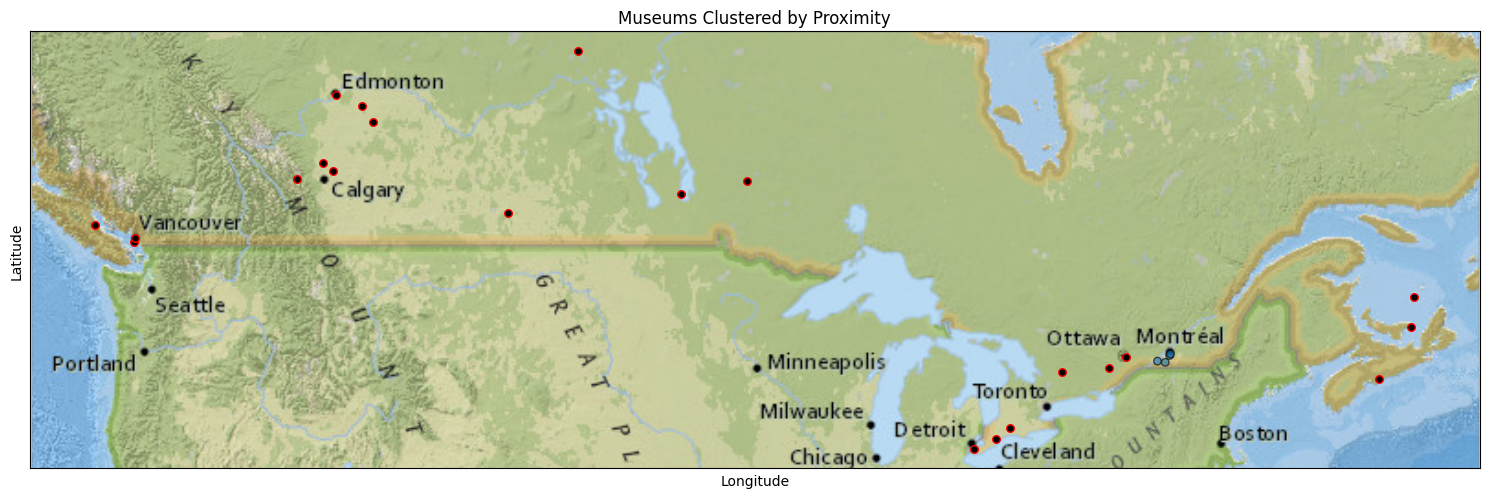

In [34]:
plot_clustered_locations(data_df, title='Museums Clustered by Proximity')

- What do you see? 
- What size is the smallest cluster? 
- Do you think the clusters make sense in terms of what you expect to see? 
- Do you think there should be more clusters in some regions? Why?


One key thing to notice here is that the clusters are not uniformly dense. 

For example, the points are quite densely packed in a few regions but are relatively sparse in between. 

DBSCAN agglomerates neighboring clusters together when they are close enough. 

Let's see how a hierarchical density-based clustering algorithm like HDBSCAN performs.


## Build an HDBSCAN clustering model
At this stage, you've already loaded your data and extracted the museum coordinates into a dataframe, df.

You've also stored properly scaled coordinates as the 'coords_scaled' array.

All that remains is to:
- Fit and transform HDBSCAN to your scaled coordinates
- Extract the cluster labels
- Plot the results on the same basemap as before

Reasonable HDBSCAN parameters have been selected for you to start with.


#### Initialize an HDBSCAN model


In [35]:
min_samples=None
min_cluster_size=3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')  # You can adjust parameters as needed

### Exercise 6. Assign the cluster labels to your unscaled coordinate dataframe and display the counts of each cluster label.


In [36]:
# Enter code here:

# Assign labels
data_df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
data_df['Cluster'].value_counts()

Cluster
0    13
1    13
Name: count, dtype: int64

<details><summary>Click here for the solution</summary>

```python
# Assign labels
df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
df['Cluster'].value_counts()
```


As you can see, unlike the case for DBSCAN, clusters quite uniformly sized, although there is a quite lot of noise identified.
### Exercise 7. Plot the hierarchically clustered museums on a basemap of Canada, colored by cluster label.


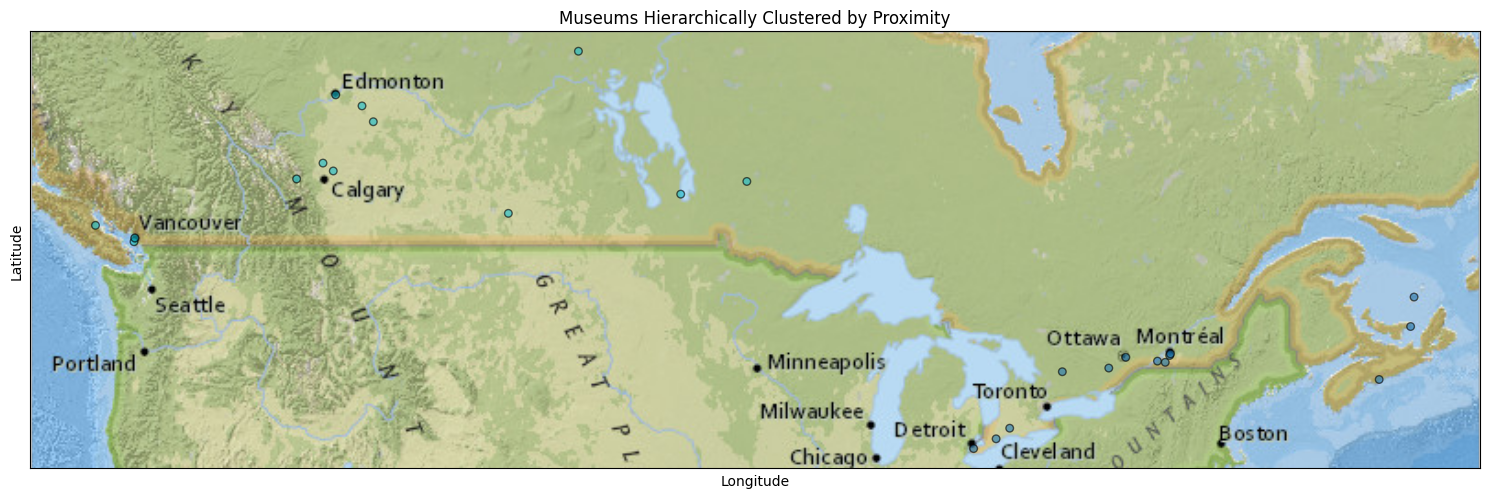

In [37]:
# Plot the museum clusters
plot_clustered_locations(data_df, title='Museums Hierarchically Clustered by Proximity')

<details><summary>Click here for the solution</summary>
    
```python
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')
```


### Closing remarks


Take a close look at the map. 
- What's different about these results compared to DBSCAN?
- It might seem like there are more points identified as noise, but is that the case?
- Can you see the variations in density that HDBSCAN captures?
- In practice, you would want to investigate much deeper but at least you get the idea here.


## Summary
Congratulations! You're ready to move on to your next lesson! In this lab, you learned how to implement DBSCAN and HDBSCAN clustering models using scikit-learn on real data from StatCan, focusing on museum locations across Canada. You also compared the performance of the two clustering techniques.

## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>


### Other Contributors

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>


<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-05 | 1.0  | Jeff Grossman    | Update content and practice exercises |
 -->


## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


